In [ ]:
import torch
from torch import nn
import torchvision.models as models
import cv2
from google.colab.patches import cv2_imshow
import PIL
from PIL import Image

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ryanholbrook/car-or-truck")

print("Path to dataset files:", path)

100%|██████████| 77.7M/77.7M [00:04<00:00, 16.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ryanholbrook/car-or-truck/versions/1


# NN


In [ ]:
model = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

for param in model.parameters():
  param.requires_grad = False

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 158MB/s]


In [ ]:
new_layer = nn.Sequential(
    nn.Linear(in_features=25088, out_features=6),
    nn.ReLU(),
    nn.Linear(6,1),
    nn.Sigmoid()
)

In [ ]:
model.classifier = new_layer
print(model.classifier)

Sequential(
  (0): Linear(in_features=25088, out_features=6, bias=True)
  (1): ReLU()
  (2): Linear(in_features=6, out_features=1, bias=True)
  (3): Sigmoid()
)


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
optim = torch.optim.Adam(params=model.parameters(), lr = 0.001)
loss_func = nn.BCELoss()
model = model.to(device)

#DataLoader

In [ ]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import os
transform  = transforms.Compose(
    [
        transforms.ToTensor()
    ]
)

train_folder = os.path.join(path, "train")
test_folder = os.path.join(path, "valid")

In [ ]:
train_dataset = datasets.ImageFolder(train_folder, transform)
test_dataset = datasets.ImageFolder(test_folder,transform=transform)
batch_size = 32
train_dataloader = DataLoader(dataset=train_dataset,batch_size=batch_size,shuffle=True)
test_dataloader = DataLoader(dataset=test_dataset,batch_size=batch_size,shuffle=True)

# Train and Validate

In [ ]:
def train(model, dataloader, optim, lossfunc):
  model.train()
  cum_loss = 0.0
  for imgs, labels in dataloader:
    imgs, labels = imgs.to(device), labels.float().view(-1,1).to(device)
    pred = model(imgs)
    loss = loss_func(pred, labels)
    optim.zero_grad()
    loss.backward() #calcula o gradiente
    optim.step()
    cum_loss += loss.item()
  return cum_loss/len(dataloader)

def test(model, dataloader, loss_func):
  model.eval()
  cum_loss = 0.0
  right = 0
  total_imgs = 0
  with torch.no_grad():
    for imgs, labels in dataloader:
      imgs, labels = imgs.to(device), labels.float().view(-1,1).to(device) #(-1,1) faz as labels estarem em formato de matriz, separando um valor de outro e permitindo a comparação
      pred = model(imgs)
      loss = loss_func(pred, labels)
      cum_loss += loss.item()
      prev = (pred >= 0.5).float()
      right += (prev == labels).sum().item()
      total_imgs += labels.size(0)
    accu = right/total_imgs
    return cum_loss/len(dataloader), accu

In [ ]:
epoch = 20
loss_arr = []

In [ ]:
for i in range (epoch):
  train_loss = train(model, train_dataloader,optim, loss_func)
  loss_arr.append(train_loss)
  print(f'Epoch: {i+1} - Loss: {train_loss}')
loss, accu = test(model, test_dataloader,loss_func)
print(f'Loss: {loss} - Accuracy: {accu}')

Epoch: 1 - Loss: 1.8451743619607443e-05
Epoch: 2 - Loss: 1.6990228931490493e-05
Epoch: 3 - Loss: 1.5364793861749602e-05
Epoch: 4 - Loss: 1.4207495719631425e-05
Epoch: 5 - Loss: 1.3153801662468822e-05
Epoch: 6 - Loss: 1.1955003853358902e-05
Epoch: 7 - Loss: 1.0747340492400782e-05
Epoch: 8 - Loss: 9.805459900746882e-06
Epoch: 9 - Loss: 8.956779811342131e-06
Epoch: 10 - Loss: 8.18064732612811e-06
Epoch: 11 - Loss: 7.500273532912161e-06
Epoch: 12 - Loss: 6.816767480444241e-06
Epoch: 13 - Loss: 6.374908218020892e-06
Epoch: 14 - Loss: 5.792681810135036e-06
Epoch: 15 - Loss: 5.144577905724646e-06
Epoch: 16 - Loss: 4.826770291188609e-06
Epoch: 17 - Loss: 4.316807587656513e-06
Epoch: 18 - Loss: 3.931139656998539e-06
Epoch: 19 - Loss: 3.694643399754227e-06
Epoch: 20 - Loss: 3.3422660948190243e-06
Loss: 1.3355082280398198 - Accuracy: 0.8833894278360721


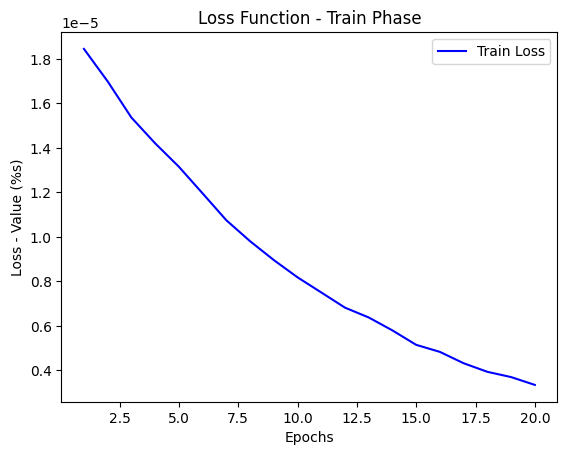

In [ ]:
import matplotlib.pyplot as plt
x = range(1,epoch + 1)
plt.plot(x, loss_arr, "b", label = "Train Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss - Value (%s)")
plt.title("Loss Function - Train Phase")
plt.legend()
plt.show()